In [ ]:
#EDA = Analyse Exploratoire des Données
import pandas as pd
import seaborn as sns

# Chargement du dataset Titanic via seaborn
df = sns.load_dataset('titanic')

In [2]:
# Afficher les 10 premières lignes
print(df.head(10))

# Nombre de lignes et de colonnes
print("Shape:", df.shape)

# Liste des colonnes et types de données
print(df.dtypes)

   survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
0         0       3    male  22.0      1      0   7.2500        S   Third   
1         1       1  female  38.0      1      0  71.2833        C   First   
2         1       3  female  26.0      0      0   7.9250        S   Third   
3         1       1  female  35.0      1      0  53.1000        S   First   
4         0       3    male  35.0      0      0   8.0500        S   Third   
5         0       3    male   NaN      0      0   8.4583        Q   Third   
6         0       1    male  54.0      0      0  51.8625        S   First   
7         0       3    male   2.0      3      1  21.0750        S   Third   
8         1       3  female  27.0      0      2  11.1333        S   Third   
9         1       2  female  14.0      1      0  30.0708        C  Second   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes

In [ ]:
#Analyse des variables:
# Variables numériques
num_vars = df.select_dtypes(include=['float64', 'int64']).columns
print("Variables numériques :", list(num_vars))

# Variables catégorielles
cat_vars = df.select_dtypes(include=['object', 'category', 'bool']).columns
print("Variables catégorielles :", list(cat_vars))

Variables numériques : ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
Variables catégorielles : ['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [ ]:
# Statistiques descriptives
print(df[num_vars].describe())

         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200


In [ ]:
#Répartition des variables catégorielles
for col in cat_vars:
    print(f"\nRépartition de {col} :")
    print(df[col].value_counts())


Répartition de sex :
sex
male      577
female    314
Name: count, dtype: int64

Répartition de embarked :
embarked
S    644
C    168
Q     77
Name: count, dtype: int64

Répartition de class :
class
Third     491
First     216
Second    184
Name: count, dtype: int64

Répartition de who :
who
man      537
woman    271
child     83
Name: count, dtype: int64

Répartition de adult_male :
adult_male
True     537
False    354
Name: count, dtype: int64

Répartition de deck :
deck
C    59
B    47
D    33
E    32
A    15
F    13
G     4
Name: count, dtype: int64

Répartition de embark_town :
embark_town
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64

Répartition de alive :
alive
no     549
yes    342
Name: count, dtype: int64

Répartition de alone :
alone
True     537
False    354
Name: count, dtype: int64


In [ ]:
#Valeurs manquantes
print(df.isnull().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [ ]:
# Valeurs aberrantes
print(df['age'].describe())
print(df['fare'].describe())

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: age, dtype: float64
count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: fare, dtype: float64


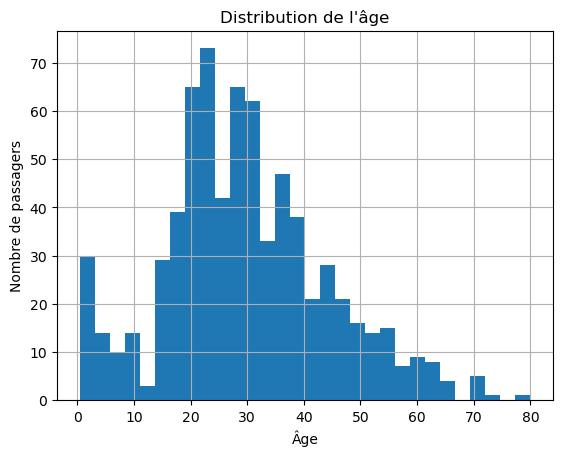

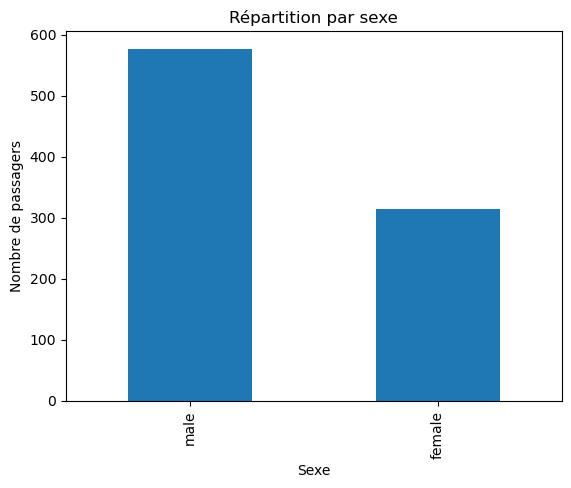

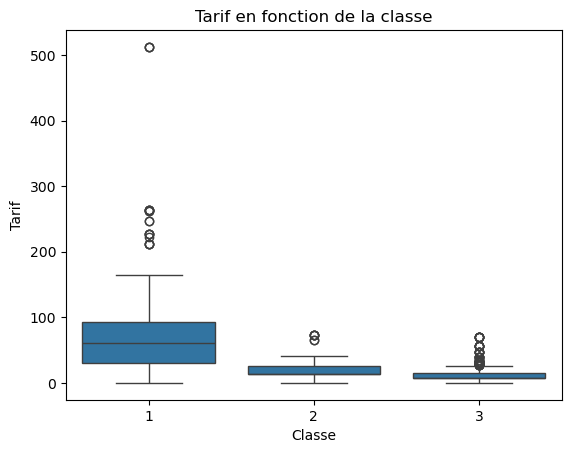

In [ ]:
# Visualisation
import matplotlib.pyplot as plt

# Histogramme de l'âge
df['age'].hist(bins=30)
plt.title("Distribution de l'âge")
plt.xlabel("Âge")
plt.ylabel("Nombre de passagers")
plt.show()

# Diagramme en barres du sexe
df['sex'].value_counts().plot(kind='bar')
plt.title("Répartition par sexe")
plt.xlabel("Sexe")
plt.ylabel("Nombre de passagers")
plt.show()

# Boxplot du tarif en fonction de la classe
sns.boxplot(x='pclass', y='fare', data=df)
plt.title("Tarif en fonction de la classe")
plt.xlabel("Classe")
plt.ylabel("Tarif")
plt.show()

In [ ]:
#Proportion de survivants
survived_counts = df['survived'].value_counts(normalize=True)
print("Proportion de survivants :")
print(survived_counts)

Proportion de survivants :
survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


In [ ]:
# Différence d’âge moyenne entre survivants et non-survivants
print(df.groupby('survived')['age'].mean())


survived
0    30.626179
1    28.343690
Name: age, dtype: float64
